# Federated Learning Experiments

Compares federated learning algorithms for PCOS detection:
1. **FedAvg** + USFM + LoRA (FL baseline)
2. **FedProx** + USFM + LoRA (non-IID tolerant)
3. **FedProto-US (Ultrasound)** (ours): prototype-based federation + LoRA
4. **FedProto-US + DP-SGD** (privacy-preserving, epsilon sweep)

Evaluation:
- Per-site and cross-site generalization (leave-one-site-out)
- External test (PCOSGen-test)
- Cross-site prototype agreement metric
- Convergence curves

In [1]:
# ============================================================
# Cell 1: Setup (same as centralized notebook)
# ============================================================
!pip install -q timm imagehash openpyxl scikit-learn gdown

import torch, torch.nn as nn, torch.nn.functional as F, types, json, os, random, time, copy
import numpy as np, subprocess, hashlib, csv, imagehash, openpyxl
from functools import partial
from collections import defaultdict
from PIL import Image
from pathlib import Path
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['Liberation Sans', 'Arimo', 'DejaVu Sans']

sys_path = __import__('sys')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Mixed-precision (fp16) config: ON when a CUDA GPU is present (e.g. Kaggle T4),
# automatically OFF on CPU so the notebook still runs anywhere.
USE_AMP = torch.cuda.is_available()
AMP_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Mixed precision (fp16): {"ENABLED" if USE_AMP else "disabled (CPU)"}')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DATA = '/kaggle/working/data/raw'
WTS = '/kaggle/working/weights'
os.makedirs(DATA, exist_ok=True)
os.makedirs(WTS, exist_ok=True)
os.makedirs('/kaggle/working/data/processed', exist_ok=True)

print(f'CUDA: {torch.cuda.is_available()}, Device: {DEVICE}')

Mixed precision (fp16): ENABLED
CUDA: True, Device: cuda


In [2]:
# ============================================================
# Cell 2: Download data + weights (same as centralized)
# ============================================================
# Reuse download code - skip if already downloaded
if not os.path.exists(f'{DATA}/pcosgen_train/PCOSGen-train/images'):
    print('Downloading PCOSGen-train...')
    subprocess.run(['curl', '-sL', '-o', f'{DATA}/PCOSGen-train.zip', 'https://zenodo.org/api/records/10430727/files/PCOSGen-train.zip/content'], check=True)
    subprocess.run(['unzip', '-q', f'{DATA}/PCOSGen-train.zip', '-d', f'{DATA}/pcosgen_train'], check=True)
    os.remove(f'{DATA}/PCOSGen-train.zip')

if not os.path.exists(f'{DATA}/pcosgen_test/images'):
    print('Downloading PCOSGen-test...')
    subprocess.run(['curl', '-sL', '-o', f'{DATA}/PCOSGen-test.zip', 'https://zenodo.org/api/records/10960327/files/PCOSGen-test.zip/content'], check=True)
    subprocess.run(['curl', '-sL', '-o', f'{DATA}/PCOSGen-test_labels.csv', 'https://zenodo.org/api/records/10960327/files/class%20label.csv/content'], check=True)
    subprocess.run(['unzip', '-q', f'{DATA}/PCOSGen-test.zip', '-d', f'{DATA}/pcosgen_test'], check=True)
    os.remove(f'{DATA}/PCOSGen-test.zip')

if not os.path.exists(f'{DATA}/figshare_pcos/PCOS'):
    print('Downloading Figshare (390MB)...')
    subprocess.run(['curl', '-sL', '-o', f'{DATA}/figshare_pcos.zip', 'https://ndownloader.figshare.com/files/50407062'], check=True)
    subprocess.run(['unzip', '-q', f'{DATA}/figshare_pcos.zip', '-d', f'{DATA}/figshare_pcos'], check=True)
    os.remove(f'{DATA}/figshare_pcos.zip')

if not os.path.exists(f'{DATA}/hanan/PCO'):
    print('Downloading HananSaadat...')
    subprocess.run(['curl', '-sL', '-o', f'{DATA}/hanan.rar', 'https://github.com/HananSaadat/ovarian_ultrasound_dataset/raw/main/ovarian_ultrasound_dataset.rar'], check=True)
    subprocess.run(['unrar', 'x', '-y', f'{DATA}/hanan.rar', f'{DATA}/hanan/'], check=True)
    os.remove(f'{DATA}/hanan.rar')

if not os.path.exists(f'{WTS}/USFM_latest.pth'):
    print('Downloading USFM weights (343MB)...')
    import gdown
    gdown.download(id='1KRwXZgYterH895Z8EpXpR1L1eSMMJo4q', output=f'{WTS}/USFM_latest.pth', quiet=False)

if not os.path.exists('/kaggle/working/USFM'):
    subprocess.run(['git', 'clone', '--depth', '1', 'https://github.com/openmedlab/USFM.git', '/kaggle/working/USFM'], check=True)

print('Downloads complete.')


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /kaggle/working/data/raw/hanan.rar

Creating    /kaggle/working/data/raw/hanan                            OK
Creating    /kaggle/working/data/raw/hanan/Dominant_Follicle          OK
Extracting  /kaggle/working/data/raw/hanan/Dominant_Follicle/desktop.ini       0%  OK 
Extracting  /kaggle/working/data/raw/hanan/Dominant_Follicle/Dominant_Follicle_1.jpg       0%  OK 
Extracting  /kaggle/working/data/raw/hanan/Dominant_Follicle/Dominant_Follicle_10.jpg       0%  OK 
Extracting  /kaggle/working/data/raw/hanan/Dominant_Follicle/Dominant_Follicle_100.jpg       0%  OK 
Extracting  /kaggle/working/data/raw/hanan/Dominant_Follicle/Dominant_Follicle_101.jpg       0%  OK 
Extracting  /kaggle/working/data/raw/hanan/Dominant_Follicle/Dominant_Follicle_102.jpg       1%  OK 
Extracting  /kaggle/working/data/raw/hanan/Dominant_Follicle/Dominant_Follicle_103.

Downloading...
From (original): https://drive.google.com/uc?id=1KRwXZgYterH895Z8EpXpR1L1eSMMJo4q
From (redirected): https://drive.google.com/uc?id=1KRwXZgYterH895Z8EpXpR1L1eSMMJo4q&confirm=t&uuid=d65ee749-ba3c-4f1c-b671-26ca42b01708
To: /kaggle/working/weights/USFM_latest.pth
100%|██████████| 343M/343M [00:03<00:00, 114MB/s]
Cloning into '/kaggle/working/USFM'...


Downloads complete.


In [3]:
# ============================================================
# Cell 3: Deduplication (same logic, produces manifest)
# ============================================================
if os.path.exists('/kaggle/working/data/processed/dataset_manifest.json'):
    print('Manifest exists - skipping dedup')
    with open('/kaggle/working/data/processed/dataset_manifest.json') as f:
        manifest = json.load(f)
else:
    print('Running deduplication...')
    # [Same dedup code as centralized notebook - included for self-containment]
    RAW = Path(DATA)
    DATASETS = {
        'pcosgen_train': RAW / 'pcosgen_train/PCOSGen-train/images',
        'pcosgen_test': RAW / 'pcosgen_test/images',
        'hanan_normal': RAW / 'hanan/Normal',
        'hanan_dominant': RAW / 'hanan/Dominant_Follicle',
        'hanan_pco': RAW / 'hanan/PCO',
        'figshare_infected': RAW / 'figshare_pcos/PCOS/infected',
        'figshare_noninfected': RAW / 'figshare_pcos/PCOS/noninfected',
    }
    records = []
    for ds_name, img_dir in DATASETS.items():
        if not img_dir.exists(): continue
        for img_path in sorted(img_dir.iterdir()):
            if img_path.suffix.lower() not in ('.jpg', '.jpeg', '.png'): continue
            try:
                img = Image.open(img_path).convert('RGB')
                ph = str(imagehash.phash(img, hash_size=16))
                ah = str(imagehash.average_hash(img, hash_size=16))
                with open(img_path, 'rb') as f: md5 = hashlib.md5(f.read()).hexdigest()
                records.append({'dataset': ds_name, 'filename': img_path.name, 'path': str(img_path), 'phash': ph, 'ahash': ah, 'md5': md5})
            except: pass
    
    def hash_to_bits(h):
        v = int(h, 16); return np.array([(v >> i) & 1 for i in range(256)], dtype=np.uint8)
    
    adj = defaultdict(set)
    md5_groups = defaultdict(list)
    for r in records: md5_groups[r['md5']].append((r['dataset'], r['filename']))
    for md5, nodes in md5_groups.items():
        if len(nodes) > 1:
            for i in range(len(nodes)):
                for j in range(i+1, len(nodes)): adj[nodes[i]].add(nodes[j]); adj[nodes[j]].add(nodes[i])
    
    by_ds = defaultdict(list)
    for r in records: by_ds[r['dataset']].append(r)
    ds_names = list(by_ds.keys())
    for i in range(len(ds_names)):
        for j in range(i+1, len(ds_names)):
            a, b = by_ds[ds_names[i]], by_ds[ds_names[j]]
            ba = np.stack([hash_to_bits(r['phash']) for r in a])
            bb = np.stack([hash_to_bits(r['phash']) for r in b])
            for ci in range(len(a)):
                dists = np.sum(ba[ci][None, :] != bb, axis=1)
                for cj in np.where(dists <= 5)[0]:
                    na, nb = (a[ci]['dataset'], a[ci]['filename']), (b[cj]['dataset'], b[cj]['filename'])
                    adj[na].add(nb); adj[nb].add(na)
    for ds_name, ds_recs in by_ds.items():
        if len(ds_recs) < 2: continue
        bits = np.stack([hash_to_bits(r['phash']) for r in ds_recs])
        N = len(ds_recs)
        for ci in range(N):
            dists = np.sum(bits[ci][None, :] != bits, axis=1)
            for cj in np.where((dists <= 5) & (np.arange(N) > ci))[0]:
                na, nb = (ds_recs[ci]['dataset'], ds_recs[ci]['filename']), (ds_recs[cj]['dataset'], ds_recs[cj]['filename'])
                adj[na].add(nb); adj[nb].add(na)
    
    visited = set(); clusters = []
    for node in list(adj.keys()):
        if node not in visited:
            cluster = set(); stack = [node]
            while stack:
                n = stack.pop()
                if n in visited: continue
                visited.add(n); cluster.add(n)
                for nb in adj[n]:
                    if nb not in visited: stack.append(nb)
            clusters.append(cluster)
    
    record_map = {(r['dataset'], r['filename']): r for r in records}
    wb = openpyxl.load_workbook(RAW / 'pcosgen_train/PCOSGen-train/class_label.xlsx')
    ws = wb.active
    pg_labels = {row[0]: int(row[1]) for row in ws.iter_rows(min_row=2, values_only=True) if row[0] and row[1] is not None}
    test_labels = {}
    with open(RAW / 'PCOSGen-test_labels.csv') as f:
        for row in csv.DictReader(f): test_labels[row['imagePath']] = int(row['Healthy'])
    
    def get_label(ds, fn):
        if ds == 'pcosgen_train':
            v = pg_labels.get(fn); return (0 if v == 1 else 1) if v is not None else None
        elif ds == 'pcosgen_test':
            v = test_labels.get(fn); return (0 if v == 1 else 1) if v is not None else None
        elif ds == 'figshare_infected': return 1
        elif ds == 'figshare_noninfected': return 0
        elif ds == 'hanan_pco': return 1
        elif ds in ('hanan_normal', 'hanan_dominant'): return 0
        return None
    
    PRIORITY = {'pcosgen_test': 0, 'pcosgen_train': 1, 'figshare_infected': 2, 'figshare_noninfected': 3, 'hanan_pco': 4, 'hanan_normal': 5, 'hanan_dominant': 6}
    SITE_MAP = {'pcosgen_train': 'site2_pcosgen', 'figshare_infected': 'site1_figshare', 'figshare_noninfected': 'site1_figshare', 'hanan_pco': 'site3_hanan', 'hanan_normal': 'site3_hanan', 'hanan_dominant': 'site3_hanan'}
    
    external_test = []; site_images = defaultdict(list)
    for cluster in clusters:
        nodes = sorted(cluster, key=lambda n: PRIORITY.get(n[0], 99))
        rep = nodes[0]; r = record_map.get(rep)
        if r is None: continue
        label = get_label(rep[0], rep[1])
        if label is None: continue
        if rep[0] == 'pcosgen_test': external_test.append({'path': r['path'], 'label': label, 'source': 'pcosgen_test'})
        else: site_images[rep[0]].append({'path': r['path'], 'label': label, 'source': rep[0]})
    for r in records:
        key = (r['dataset'], r['filename'])
        if key in visited: continue
        label = get_label(r['dataset'], r['filename'])
        if label is None: continue
        if r['dataset'] == 'pcosgen_test': external_test.append({'path': r['path'], 'label': label, 'source': 'pcosgen_test'})
        else: site_images[r['dataset']].append({'path': r['path'], 'label': label, 'source': r['dataset']})
    
    final_sites = defaultdict(list)
    for ds, imgs in site_images.items(): final_sites[SITE_MAP.get(ds, ds)].extend(imgs)
    
    def stratified_split(images, train_frac=0.70, val_frac=0.15, seed=42):
        rng = random.Random(seed); by_label = defaultdict(list)
        for img in images: by_label[img['label']].append(img)
        splits = {'train': [], 'val': [], 'test': []}
        for label, imgs in by_label.items():
            rng.shuffle(imgs); n = len(imgs); nt, nv = int(n * train_frac), int(n * val_frac)
            splits['train'].extend(imgs[:nt]); splits['val'].extend(imgs[nt:nt+nv]); splits['test'].extend(imgs[nt+nv:])
        for s in splits.values(): rng.shuffle(s)
        return splits
    
    manifest = {}
    for sn in sorted(final_sites.keys()): manifest[sn] = stratified_split(final_sites[sn])
    manifest['external_test'] = {'train': [], 'val': [], 'test': external_test}
    with open('/kaggle/working/data/processed/dataset_manifest.json', 'w') as f:
        json.dump(manifest, f, indent=2)
    print('Dedup complete.')

for sn in sorted(manifest.keys()):
    if sn == 'external_test': print(f'  {sn}: {len(manifest[sn]["test"])} test')
    else:
        s = manifest[sn]
        print(f'  {sn}: train={len(s["train"])}, val={len(s["val"])}, test={len(s["test"])}')

Running deduplication...
Dedup complete.
  external_test: 1411 test
  site1_figshare: train=1078, val=230, test=234
  site2_pcosgen: train=2040, val=436, test=439
  site3_hanan: train=209, val=44, test=46


In [4]:
import numpy as np
# ============================================================
# Cell 4: Model components (same as centralized)
# ============================================================
import torch, torch.nn as nn, torch.nn.functional as F, types
from functools import partial
import sys, json, os, random, time, numpy as np
from PIL import Image
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, confusion_matrix

sys.path.insert(0, '/kaggle/working/USFM')
from usdsgen.modules.backbone.vision_transformer import VisionTransformer

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

# ImageNet normalization constants (used to un-normalize for the foreground mask)
import scipy.ndimage as _ndi
_IMNET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
_IMNET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

def compute_patch_mask(x, grid=14, fan_thr=0.06, erode_px=6, cover_frac=0.80,
                       low_thr=0.15, high_thr=0.82, std_thr=0.09):
    """Anatomical tissue mask over the ViT patch grid (14x14).
    x: (B,3,224,224) ImageNet-normalized batch. Returns (B, grid*grid) bool:
    True = ovarian/anatomical tissue patch, False = non-anatomical region.

    A patch is TISSUE only if ALL hold:
      (1) it lies inside the ultrasound acquisition fan, ERODED inward by
          `erode_px` px so the fan-boundary rim is excluded. The fan is the
          largest bright connected component (luminance > fan_thr), hole-filled.
          A patch counts as in-fan if >= cover_frac of its pixels are inside.
      (2) its mean luminance is in [low_thr, high_thr] -> removes residual black
          sector corners AND bright UI banners / caliper overlays.
      (3) its luminance std >= std_thr -> removes flat dead zones.
    Prevents prototypes AND the clustering loss from attaching to acquisition
    artifacts (sector margins, fan rim, banners/calipers, transducer). If an
    image yields zero tissue patches (rare tiny scans) callers fall back to all
    patches so no NaN/Inf appears. v1 used only per-patch mean/std, which let
    fan-EDGE patches (mixed black+bright => high std) pass; step (1) fixes that."""
    device = x.device
    mean = _IMNET_MEAN.to(device); std = _IMNET_STD.to(device)
    img = x * std + mean                          # un-normalize -> [0,1]
    gray = img.mean(dim=1, keepdim=True)          # (B,1,224,224) luminance
    P = img.shape[-1] // grid                     # patch size in px (16)
    patch_mean = F.avg_pool2d(gray, kernel_size=P, stride=P).flatten(1)   # (B, g*g)
    patch_sq   = F.avg_pool2d(gray ** 2, kernel_size=P, stride=P).flatten(1)
    patch_std  = (patch_sq - patch_mean ** 2).clamp_min(0).sqrt()          # (B, g*g)
    bright_ok  = (patch_mean >= low_thr) & (patch_mean <= high_thr) & (patch_std >= std_thr)
    # --- fan region (numpy per image): largest bright CC, fill holes, erode inward ---
    g_np = gray[:, 0].detach().cpu().numpy()
    B = x.shape[0]
    infan = torch.zeros((B, grid * grid), dtype=torch.bool)
    for b in range(B):
        gg = g_np[b]
        binm = gg > fan_thr
        lbl, n = _ndi.label(binm)
        if n == 0:
            continue
        sizes = _ndi.sum(np.ones_like(lbl), lbl, index=range(1, n + 1))
        big = (lbl == (int(np.argmax(sizes)) + 1))
        big = _ndi.binary_fill_holes(big)
        if erode_px > 0:
            big = _ndi.binary_erosion(big, iterations=erode_px)
        cov = big.astype(np.float32).reshape(grid, P, grid, P).mean(axis=(1, 3))  # (g,g)
        infan[b] = torch.from_numpy((cov >= cover_frac).reshape(-1))
    fg = infan.to(device) & bright_ok
    return fg

def apply_lora(backbone, rank=8):
    all_lora = []
    for block in backbone.blocks:
        attn = block.attn
        in_dim = attn.qkv.weight.shape[1]; out_dim = attn.qkv.weight.shape[0]
        lora_qkv_A = nn.Parameter(torch.zeros(rank, in_dim))
        lora_qkv_B = nn.Parameter(torch.zeros(out_dim, rank))
        lora_proj_A = nn.Parameter(torch.zeros(rank, in_dim))
        lora_proj_B = nn.Parameter(torch.zeros(in_dim, rank))
        nn.init.kaiming_uniform_(lora_qkv_A, a=5**0.5)
        nn.init.kaiming_uniform_(lora_proj_A, a=5**0.5)
        attn.lora_qkv_A = lora_qkv_A; attn.lora_qkv_B = lora_qkv_B
        attn.lora_proj_A = lora_proj_A; attn.lora_proj_B = lora_proj_B
        all_lora.extend([lora_qkv_A, lora_qkv_B, lora_proj_A, lora_proj_B])

        def make_fwd():
            def lora_fwd(self, x, rel_pos_bias=None):
                B, N, C = x.shape
                qkv_bias = None
                if self.q_bias is not None:
                    qkv_bias = torch.cat((self.q_bias, torch.zeros_like(self.v_bias, requires_grad=False), self.v_bias))
                qkv = F.linear(input=x, weight=self.qkv.weight, bias=qkv_bias)
                qkv = qkv + F.linear(F.linear(x, self.lora_qkv_A), self.lora_qkv_B)
                qkv = qkv.reshape(B, N, 3, self.num_heads, -1).permute(2, 0, 3, 1, 4)
                q, k, v = qkv[0], qkv[1], qkv[2]
                q = q * self.scale
                attn = q @ k.transpose(-2, -1)
                if self.relative_position_bias_table is not None:
                    rpb = self.relative_position_bias_table[self.relative_position_index.view(-1)].view(
                        self.window_size[0]*self.window_size[1]+1, self.window_size[0]*self.window_size[1]+1, -1)
                    attn = attn + rpb.permute(2, 0, 1).contiguous().unsqueeze(0)
                if rel_pos_bias is not None: attn = attn + rel_pos_bias
                attn = attn.softmax(dim=-1); attn = self.attn_drop(attn)
                x = (attn @ v).transpose(1, 2).reshape(B, N, -1)
                x = self.proj(x) + F.linear(F.linear(x, self.lora_proj_A), self.lora_proj_B)
                x = self.proj_drop(x)
                return x
            return lora_fwd
        attn.forward = types.MethodType(make_fwd(), attn)
    return all_lora

# --- ProtoPNet layer ---
class ProtoPNetLayer(nn.Module):
    def __init__(self, embed_dim=768, num_classes=2, proto_per_class=10):
        super().__init__()
        self.num_classes = num_classes; self.proto_per_class = proto_per_class
        self.num_prototypes = num_classes * proto_per_class; self.embed_dim = embed_dim
        self.prototypes = nn.Parameter(torch.randn(self.num_prototypes, embed_dim) * 0.01)

    def get_min_distances(self, patch_features, patch_mask=None):
        """patch_features: (B,N,D). patch_mask: (B,N) bool foreground mask or None.
        When a mask is given, background patches are excluded from the per-image
        min (set to +inf). Images with zero foreground fall back to all patches so
        no NaN/Inf can appear."""
        B, N, D = patch_features.shape
        x_norm = F.normalize(patch_features, dim=-1)
        p_norm = F.normalize(self.prototypes, dim=-1)
        dot = torch.matmul(x_norm, p_norm.t())          # (B,N,P)
        dist = 2.0 - 2.0 * dot                           # cosine distance in [0,2]
        if patch_mask is not None:
            m = patch_mask.to(dist.device).clone()
            no_fg = (m.sum(dim=1) == 0)                   # images with no tissue
            if no_fg.any(): m[no_fg] = True               # fallback: keep all patches
            neg = torch.full_like(dist, float('inf'))
            dist = torch.where(m.unsqueeze(-1), dist, neg)
        return dist.min(dim=1)[0]                         # (B,P)

    def forward(self, patch_features, patch_mask=None):
        return -self.get_min_distances(patch_features, patch_mask=patch_mask)

    def project_prototypes(self, patch_features_list, labels_list, mask_list=None):
        """Project each prototype onto its nearest FOREGROUND training patch,
        with robust farthest-point diversity (see below). If mask_list is provided,
        only tissue patches are candidates -> prototypes never land on background."""
        proto_device = self.prototypes.device
        protos_cpu = self.prototypes.detach().cpu()
        all_patches, all_labels, all_masks = [], [], []
        have_mask = mask_list is not None
        for bi, (pf, labs) in enumerate(zip(patch_features_list, labels_list)):
            pf_cpu = pf.detach().cpu()
            n_imgs, n_patches, D = pf_cpu.shape
            mk = mask_list[bi].detach().cpu() if have_mask else None
            for i in range(n_imgs):
                all_patches.append(pf_cpu[i])            # (n_patches, D)
                all_labels.append(labs[i].item())
                if have_mask: all_masks.append(mk[i])    # (n_patches,) bool
        all_patches = torch.stack(all_patches)           # (num_images, n_patches, D)
        num_images, n_patches, D = all_patches.shape
        all_labels = torch.tensor(all_labels)
        all_labels_expanded = all_labels.unsqueeze(1).expand(num_images, n_patches).reshape(-1)
        all_patches_flat = all_patches.reshape(-1, self.embed_dim)
        all_patches_norm = F.normalize(all_patches_flat, dim=-1)
        if have_mask:
            fg_flat = torch.stack(all_masks).reshape(-1).bool()   # (num_images*n_patches,)
            # --- LOUD MASK GUARD (prevents the silent 'mask did nothing' bug) ---
            # If the mask works it should exclude a substantial fraction of patches
            # (background/borders/UI). If ~0% are excluded the mask silently failed and
            # prototypes would snap to background (broken gallery). If ~100% are excluded,
            # over-masking starves projection. Either way we FAIL LOUDLY here, in-run.
            _fg_frac = float(fg_flat.float().mean())
            print(f'[MASK CHECK] project_prototypes foreground fraction = {_fg_frac:.3f} '
                  f'({int(fg_flat.sum())}/{fg_flat.numel()} patches kept)')
            assert _fg_frac < 0.98, (
                f'MASK SILENTLY FAILED: {_fg_frac:.3f} of patches are foreground '
                f'(expected well below 0.98); prototypes would land on background. '
                f'Check compute_patch_mask actually runs before projection.')
            assert _fg_frac > 0.02, (
                f'MASK OVER-EXCLUDES: only {_fg_frac:.3f} of patches are foreground '
                f'(expected well above 0.02); projection would be starved.')
        else:
            fg_flat = torch.ones(all_patches_norm.shape[0], dtype=torch.bool)
        # --- Robust diverse projection (foreground-only candidates) ---
        # Assign each prototype to its nearest candidate patch whose max cosine to
        # the already-assigned prototypes (same class) is < div_thresh. If none
        # passes (dominant recurring pattern), fall back to FARTHEST-POINT sampling
        # (minimize max-cosine to assigned set). Guarantees distinct, tissue-only
        # prototypes and prevents the collapse failure mode.
        div_thresh = getattr(self, 'proj_div_thresh', 0.92)
        for c in range(self.num_classes):
            sel = (all_labels_expanded == c) & fg_flat
            if sel.sum() < self.proto_per_class:          # too few tissue patches
                sel = (all_labels_expanded == c)          # fallback: all patches
            if sel.sum() == 0:
                continue
            cp = all_patches_norm[sel]                    # (Nc, D) normalized
            assigned = []
            for k in range(self.proto_per_class):
                idx = c * self.proto_per_class + k
                proto_norm = F.normalize(protos_cpu[idx].unsqueeze(0), dim=-1)
                dists = torch.norm(cp - proto_norm, dim=1)
                order = torch.argsort(dists)
                if not assigned:
                    chosen = cp[order[0]]
                else:
                    A = torch.stack(assigned)
                    max_cos = (cp @ A.t()).max(dim=1)[0]
                    ok = max_cos < div_thresh
                    chosen = None
                    for ci in order:
                        if ok[ci]:
                            chosen = cp[ci]; break
                    if chosen is None:
                        chosen = cp[torch.argmin(max_cos)]
                protos_cpu[idx] = chosen.clone()
                assigned.append(F.normalize(chosen.unsqueeze(0), dim=-1).squeeze(0))
        self.prototypes.data = protos_cpu.to(proto_device)

# --- Full model ---
class FedProtoUSModel(nn.Module):
    def __init__(self, backbone, lora_params, proto_layer, num_classes=2):
        super().__init__()
        self.backbone = backbone; self.proto_layer = proto_layer
        self.classifier = nn.Linear(proto_layer.num_prototypes, num_classes, bias=False)
        with torch.no_grad():
            for c in range(num_classes):
                for k in range(proto_layer.proto_per_class):
                    idx = c * proto_layer.proto_per_class + k
                    self.classifier.weight[c, idx] = 1.0
                    for oc in range(num_classes):
                        if oc != c: self.classifier.weight[oc, idx] = -0.5

    def get_patch_features(self, x):
        B = x.shape[0]
        x = self.backbone.patch_embed(x)
        x = torch.cat((self.backbone.cls_token.expand(B, -1, -1), x), dim=1)
        if self.backbone.pos_embed is not None: x = x + self.backbone.pos_embed
        x = self.backbone.pos_drop(x)
        rpb = self.backbone.rel_pos_bias() if self.backbone.rel_pos_bias is not None else None
        for blk in self.backbone.blocks: x = blk(x, rel_pos_bias=rpb)
        x = self.backbone.norm(x)
        pt = x[:, 1:, :]
        if self.backbone.fc_norm is not None: pt = self.backbone.fc_norm(pt)
        return pt

    def forward(self, x, return_mask=False):
        pf = self.get_patch_features(x)
        pmask = compute_patch_mask(x)                     # (B,196) tissue mask
        sims = self.proto_layer(pf, patch_mask=pmask)     # background-excluded sims
        logits = self.classifier(sims)
        if return_mask:
            return logits, sims, pf, pmask
        return logits, sims, pf

# --- Loss ---
def prototype_diversity_loss(proto_layer, min_margin=0.3):
    """Within-class diversity regularizer: penalizes pairs of prototypes in the
    SAME class more similar than (1 - min_margin) in cosine space. Prevents
    prototype collapse (multiple prototypes converging to one visual pattern)."""
    pn = F.normalize(proto_layer.prototypes, dim=-1)
    K = proto_layer.proto_per_class
    div = 0.0; n = 0
    for c in range(proto_layer.num_classes):
        ps, pe = c * K, (c + 1) * K
        block = pn[ps:pe] @ pn[ps:pe].t()
        off = block[~torch.eye(K, dtype=torch.bool, device=block.device)]
        div = div + F.relu(off - (1.0 - min_margin)).mean()
        n += 1
    return div / max(n, 1)

def protopnet_loss(logits, labels, proto_layer, patch_feats, patch_mask=None,
                   lambda_clst=0.8, lambda_sep=0.08, lambda_div=0.5,
                   min_margin=0.3, use_proto=True):
    cls_loss = F.cross_entropy(logits, labels)
    if not use_proto:
        z = torch.tensor(0.0, device=labels.device)
        return cls_loss, cls_loss, z, z, z
    # Foreground-masked min distances: prototype losses ignore background patches.
    min_dists = proto_layer.get_min_distances(patch_feats, patch_mask=patch_mask)
    K = proto_layer.proto_per_class; clst = 0.; sep = 0.
    for c in range(proto_layer.num_classes):
        ps, pe = c * K, (c + 1) * K
        sm, om = (labels == c), (labels != c)
        if sm.sum() > 0: clst += min_dists[sm, ps:pe].min(dim=1)[0].mean()
        if om.sum() > 0: sep += min_dists[om, ps:pe].min(dim=1)[0].mean()
    div = prototype_diversity_loss(proto_layer, min_margin=min_margin)
    total = cls_loss + lambda_clst * clst + lambda_sep * (-sep) + lambda_div * div
    return total, cls_loss, clst, sep, div

# --- Dataset ---
class PCOSDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform or T.Compose([
            T.Resize((224, 224)), T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        s = self.samples[idx]
        return self.transform(Image.open(s['path']).convert('RGB')), s['label']


# --- Model factory: assemble USFM backbone + LoRA + prototype layer ---
# Returns (model, lora_params, trainable_params, proto_layer). Called by the FL
# routines (run_fedavg / run_fedprox / run_fedproto_us) to create a fresh model.
def build_model():
    backbone = VisionTransformer(
        img_size=224, patch_size=16, in_chans=3, num_classes=0,
        embed_dim=768, depth=12, num_heads=12, mlp_ratio=4.0,
        qkv_bias=True, norm_layer=partial(nn.LayerNorm, eps=1e-6),
        init_values=1e-5, use_abs_pos_emb=True,
        use_rel_pos_bias=True, use_shared_rel_pos_bias=True,
        use_mean_pooling=True,
    )
    ckpt = torch.load(f'{WTS}/USFM_latest.pth', map_location='cpu', weights_only=False)
    backbone.load_state_dict(ckpt, strict=False)
    for p in backbone.parameters(): p.requires_grad = False
    backbone.eval()

    lora_params = apply_lora(backbone, rank=8)
    proto_layer = ProtoPNetLayer(768, 2, 10)
    model = FedProtoUSModel(backbone, lora_params, proto_layer, 2).to(DEVICE)

    trainable = list(lora_params) + [proto_layer.prototypes, model.classifier.weight]
    return model, lora_params, trainable, proto_layer

print('Model components defined.')


Model components defined.


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [5]:
# ============================================================
# Cell 5: FL infrastructure
# ============================================================

SITE_NAMES = ['site1_figshare', 'site2_pcosgen', 'site3_hanan']

def get_lora_state(model):
    """Extract LoRA params as a dict for federation."""
    state = {}
    for i, block in enumerate(model.backbone.blocks):
        attn = block.attn
        state[i] = {'qkv_A': attn.lora_qkv_A.data.clone(), 'qkv_B': attn.lora_qkv_B.data.clone(),
                     'proj_A': attn.lora_proj_A.data.clone(), 'proj_B': attn.lora_proj_B.data.clone()}
    return state

def set_lora_state(model, state):
    """Load LoRA params from a dict."""
    for i, block in enumerate(model.backbone.blocks):
        attn = block.attn
        attn.lora_qkv_A.data = state[i]['qkv_A'].clone()
        attn.lora_qkv_B.data = state[i]['qkv_B'].clone()
        attn.lora_proj_A.data = state[i]['proj_A'].clone()
        attn.lora_proj_B.data = state[i]['proj_B'].clone()

def get_trainable_params(model):
    """Get all trainable params (LoRA + prototypes + classifier)."""
    params = []
    for block in model.backbone.blocks:
        attn = block.attn
        params.extend([attn.lora_qkv_A, attn.lora_qkv_B, attn.lora_proj_A, attn.lora_proj_B])
    params.extend([model.proto_layer.prototypes, model.classifier.weight])
    return params

def evaluate_model(model, samples, batch_size=32):
    """Evaluate model on a set of samples."""
    model.eval()
    loader = DataLoader(PCOSDataset(samples), batch_size=batch_size, shuffle=False, num_workers=2)
    probs, labels = [], []
    with torch.no_grad():
        for images, labs in loader:
            logits, _, _ = model(images.to(DEVICE))
            probs.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())
            labels.extend(labs.numpy())
    preds = [1 if p > 0.5 else 0 for p in probs]
    auc = roc_auc_score(labels, probs) if len(set(labels)) > 1 else 0
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='binary', zero_division=0)
    cm = confusion_matrix(labels, preds, labels=[0, 1])
    sens = cm[1, 1] / max(cm[1, 0] + cm[1, 1], 1)
    spec = cm[0, 0] / max(cm[0, 0] + cm[0, 1], 1)
    return {'auc': auc, 'acc': acc, 'f1': f1, 'sensitivity': sens, 'specificity': spec}

print('FL infrastructure defined.')

FL infrastructure defined.


In [6]:
# ============================================================
# Cell 6: FedAvg implementation
# ============================================================

def fedavg_round(global_lora, client_lora_list, client_sizes):
    """FedAvg aggregation: weighted average of LoRA params."""
    total_size = sum(client_sizes)
    aggregated = {}
    for i in range(12):  # 12 blocks
        aggregated[i] = {}
        for key in ['qkv_A', 'qkv_B', 'proj_A', 'proj_B']:
            weighted_sum = sum(client_lora_list[c][i][key] * client_sizes[c] for c in range(len(client_lora_list)))
            aggregated[i][key] = weighted_sum / total_size
    return aggregated

def run_fedavg(num_rounds=15, local_epochs=2, lr=5e-4, batch_size=32, seed=42):
    """Run FedAvg with USFM + LoRA (no prototypes, standard linear head)."""
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    
    # Initialize global model
    global_model, _, _, _ = build_model()
    global_lora = get_lora_state(global_model)
    
    # Per-site data loaders
    site_loaders = {}
    site_sizes = {}
    for site in SITE_NAMES:
        samples = manifest[site]['train']
        site_loaders[site] = DataLoader(PCOSDataset(samples), batch_size=batch_size, shuffle=True, num_workers=2)
        site_sizes[site] = len(samples)
    
    history = []
    for rnd in range(num_rounds):
        t0 = time.time()
        client_lora_list = []
        client_sizes_list = []
        
        for site in SITE_NAMES:
            # Set global LoRA
            set_lora_state(global_model, global_lora)
            global_model.train(); global_model.backbone.eval()
            
            # Local training (no prototype loss - just cls)
            trainable = get_trainable_params(global_model)
            optimizer = torch.optim.Adam(trainable, lr=lr, weight_decay=1e-4)
            scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)
            
            for epoch in range(local_epochs):
                for images, labels in site_loaders[site]:
                    images, labels = images.to(DEVICE), labels.to(DEVICE)
                    optimizer.zero_grad()
                    with torch.autocast(device_type=AMP_DEVICE, dtype=torch.float16, enabled=USE_AMP):
                        logits, _, _ = global_model(images)
                        loss = F.cross_entropy(logits, labels)
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
            
            client_lora_list.append(get_lora_state(global_model))
            client_sizes_list.append(site_sizes[site])
        
        # Aggregate
        global_lora = fedavg_round(global_lora, client_lora_list, client_sizes_list)
        set_lora_state(global_model, global_lora)
        
        # Evaluate on all val sets
        val_metrics = {}
        for site in SITE_NAMES:
            val_metrics[site] = evaluate_model(global_model, manifest[site]['val'])
        
        # Pooled val
        all_val = []
        for site in SITE_NAMES: all_val.extend(manifest[site]['val'])
        pooled = evaluate_model(global_model, all_val)
        
        elapsed = time.time() - t0
        print(f'FedAvg R{rnd+1}/{num_rounds} ({elapsed:.0f}s): pooled AUC={pooled["auc"]:.3f} acc={pooled["acc"]:.3f}')
        history.append({'round': rnd+1, 'pooled': pooled, 'per_site': val_metrics})
    
    return global_model, history

print('FedAvg defined.')

FedAvg defined.


In [7]:
# ============================================================
# Cell 7: FedProx implementation
# ============================================================

def run_fedprox(num_rounds=15, local_epochs=2, lr=5e-4, mu=0.01, batch_size=32, seed=42):
    """FedProx: FedAvg + proximal regularization for non-IID tolerance."""
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    
    global_model, _, _, _ = build_model()
    global_lora = get_lora_state(global_model)
    
    site_loaders = {}; site_sizes = {}
    for site in SITE_NAMES:
        samples = manifest[site]['train']
        site_loaders[site] = DataLoader(PCOSDataset(samples), batch_size=batch_size, shuffle=True, num_workers=2)
        site_sizes[site] = len(samples)
    
    history = []
    for rnd in range(num_rounds):
        t0 = time.time()
        client_lora_list = []; client_sizes_list = []
        
        for site in SITE_NAMES:
            set_lora_state(global_model, global_lora)
            global_model.train(); global_model.backbone.eval()
            
            # Store global params for proximal term
            global_params = {}
            for i, block in enumerate(global_model.backbone.blocks):
                attn = block.attn
                for key, param in [('qkv_A', attn.lora_qkv_A), ('qkv_B', attn.lora_qkv_B),
                                   ('proj_A', attn.lora_proj_A), ('proj_B', attn.lora_proj_B)]:
                    global_params[f'{i}_{key}'] = param.data.clone()
            
            trainable = get_trainable_params(global_model)
            optimizer = torch.optim.Adam(trainable, lr=lr, weight_decay=1e-4)
            scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)
            
            for epoch in range(local_epochs):
                for images, labels in site_loaders[site]:
                    images, labels = images.to(DEVICE), labels.to(DEVICE)
                    optimizer.zero_grad()
                    with torch.autocast(device_type=AMP_DEVICE, dtype=torch.float16, enabled=USE_AMP):
                        logits, _, _ = global_model(images)
                        cls_loss = F.cross_entropy(logits, labels)
                    # Proximal term computed in fp32 (parameter-space penalty).
                    prox_loss = 0.
                    for i, block in enumerate(global_model.backbone.blocks):
                        attn = block.attn
                        for key, param in [('qkv_A', attn.lora_qkv_A), ('qkv_B', attn.lora_qkv_B),
                                           ('proj_A', attn.lora_proj_A), ('proj_B', attn.lora_proj_B)]:
                            prox_loss += ((param - global_params[f'{i}_{key}']) ** 2).sum()
                    
                    loss = cls_loss.float() + (mu / 2) * prox_loss
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
            
            client_lora_list.append(get_lora_state(global_model))
            client_sizes_list.append(site_sizes[site])
        
        global_lora = fedavg_round(global_lora, client_lora_list, client_sizes_list)
        set_lora_state(global_model, global_lora)
        
        val_metrics = {}
        for site in SITE_NAMES: val_metrics[site] = evaluate_model(global_model, manifest[site]['val'])
        all_val = []
        for site in SITE_NAMES: all_val.extend(manifest[site]['val'])
        pooled = evaluate_model(global_model, all_val)
        
        elapsed = time.time() - t0
        print(f'FedProx R{rnd+1}/{num_rounds} ({elapsed:.0f}s): pooled AUC={pooled["auc"]:.3f} acc={pooled["acc"]:.3f}')
        history.append({'round': rnd+1, 'pooled': pooled, 'per_site': val_metrics})
    
    return global_model, history

print('FedProx defined.')

FedProx defined.


In [8]:
# ============================================================
# Cell 8: FedProto-US (our method)
# ============================================================

def aggregate_prototypes(client_protos_list, client_sizes, num_classes=2, proto_per_class=10):
    """Aggregate prototypes via per-class weighted k-means clustering.
    
    Weighted averaging of projected prototypes is mathematically wrong because
    each site snaps prototypes to DIFFERENT local patches — averaging two
    prototypes snapped to different images produces a meaningless centroid.
    Instead, we collect all client prototypes per class and run weighted
    k-means (k=proto_per_class) to find K representative cluster centers.
    """
    from sklearn.cluster import KMeans
    global_protos = torch.zeros(num_classes * proto_per_class, 768, device=DEVICE)
    for c in range(num_classes):
        # Collect all prototypes for this class from all clients
        class_protos = []
        weights = []
        for ci, (protos, size) in enumerate(zip(client_protos_list, client_sizes)):
            for k in range(proto_per_class):
                idx = c * proto_per_class + k
                class_protos.append(protos[idx].cpu().numpy())
                weights.append(size)
        class_protos = np.array(class_protos)
        weights = np.array(weights, dtype=float)
        # Weighted k-means: initialize with weighted mean, then cluster
        # Use k-means++ init with the actual prototypes, weighted by client size
        if len(class_protos) >= proto_per_class:
            kmeans = KMeans(n_clusters=proto_per_class, init='k-means++',
                           n_init=10, random_state=42)
            kmeans.fit(class_protos, sample_weight=weights)
            centers = kmeans.cluster_centers_
        else:
            # Fallback: if fewer prototypes than clusters, pad with weighted mean
            weighted_mean = (class_protos * weights[:, None]).sum(0) / weights.sum()
            centers = np.tile(weighted_mean, (proto_per_class, 1))
            centers[:len(class_protos)] = class_protos
        # Normalize and store
        for k in range(proto_per_class):
            idx = c * proto_per_class + k
            center = torch.tensor(centers[k], dtype=torch.float32, device=DEVICE)
            global_protos[idx] = F.normalize(center.unsqueeze(0), dim=-1).squeeze(0)
    return global_protos

def cross_site_agreement(site_protos_list, num_classes=2, proto_per_class=10):
    """Compute cross-site prototype agreement metric.
    Agreement(i,j) = (1/KC) * sum_c sum_k max_k' cos(p_{c,k}^i, p_{c,k'}^j)
    """
    n_sites = len(site_protos_list)
    agreement = np.zeros((n_sites, n_sites))
    for i in range(n_sites):
        for j in range(n_sites):
            if i == j:
                agreement[i, j] = 1.0
                continue
            total = 0.
            for c in range(num_classes):
                for k in range(proto_per_class):
                    idx = c * proto_per_class + k
                    pi = site_protos_list[i][idx]
                    # Find max cosine similarity with any prototype at site j
                    best = -1.
                    for kp in range(proto_per_class):
                        idxp = c * proto_per_class + kp
                        pj = site_protos_list[j][idxp]
                        cos_sim = F.cosine_similarity(pi.unsqueeze(0), pj.unsqueeze(0)).item()
                        best = max(best, cos_sim)
                    total += best
            agreement[i, j] = total / (num_classes * proto_per_class)
    return agreement

def run_fedproto_us(num_rounds=15, local_epochs=2, lr=5e-4, batch_size=32,
                    warmup_rounds=3, proj_every=3, use_dp=False, epsilon=None,
                    dp_clip=1.0, dp_noise=0.1, seed=42):
    """FedProto-US: federate prototypes + LoRA, with optional DP-SGD."""
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    
    global_model, _, _, proto_layer = build_model()
    global_lora = get_lora_state(global_model)
    global_protos = proto_layer.prototypes.data.clone()
    
    site_loaders = {}; site_sizes = {}
    for site in SITE_NAMES:
        samples = manifest[site]['train']
        site_loaders[site] = DataLoader(PCOSDataset(samples), batch_size=batch_size, shuffle=True, num_workers=2)
        site_sizes[site] = len(samples)
    
    history = []
    all_site_protos = []  # for agreement metric at end
    
    for rnd in range(num_rounds):
        t0 = time.time()
        client_lora_list = []; client_protos_list = []; client_sizes_list = []
        site_protos_this_round = []
        
        use_proto = (rnd >= warmup_rounds)
        
        for site in SITE_NAMES:
            set_lora_state(global_model, global_lora)
            global_model.proto_layer.prototypes.data = global_protos.clone()
            global_model.train(); global_model.backbone.eval()
            
            trainable = get_trainable_params(global_model)
            optimizer = torch.optim.Adam(trainable, lr=lr, weight_decay=1e-4)
            scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)
            
            for epoch in range(local_epochs):
                for images, labels in site_loaders[site]:
                    images, labels = images.to(DEVICE), labels.to(DEVICE)
                    optimizer.zero_grad()
                    with torch.autocast(device_type=AMP_DEVICE, dtype=torch.float16, enabled=USE_AMP):
                        logits, sims, pf, pmask = global_model(images, return_mask=True)
                        loss, _, _, _, _ = protopnet_loss(logits, labels, global_model.proto_layer, pf, patch_mask=pmask, use_proto=use_proto)
                    scaler.scale(loss).backward()
                    
                    # DP-SGD: clip gradients + add noise (on TRUE-scale grads).
                    # Must unscale before touching .grad so clip norm + noise are correct.
                    if use_dp and epsilon is not None:
                        scaler.unscale_(optimizer)
                        torch.nn.utils.clip_grad_norm_(trainable, dp_clip)
                        for p in trainable:
                            if p.grad is not None:
                                noise = torch.randn_like(p.grad) * dp_noise
                                p.grad += noise
                    
                    scaler.step(optimizer)
                    scaler.update()
            
            # Local prototype projection
            if use_proto and (rnd + 1) % proj_every == 0:
                global_model.eval()
                pf_list, lab_list, mask_list = [], [], []
                with torch.no_grad():
                    for images, labels in site_loaders[site]:
                        imgs = images.to(DEVICE)
                        pf_list.append(global_model.get_patch_features(imgs).detach().cpu())
                        mask_list.append(compute_patch_mask(imgs).detach().cpu())
                        lab_list.append(labels)
                global_model.proto_layer.project_prototypes(pf_list, lab_list, mask_list=mask_list)
            
            client_lora_list.append(get_lora_state(global_model))
            client_protos_list.append(global_model.proto_layer.prototypes.data.clone())
            client_sizes_list.append(site_sizes[site])
            site_protos_this_round.append(global_model.proto_layer.prototypes.data.clone())
        
        # Aggregate LoRA (FedAvg-style)
        global_lora = fedavg_round(global_lora, client_lora_list, client_sizes_list)
        # Aggregate prototypes
        global_protos = aggregate_prototypes(client_protos_list, client_sizes_list)
        
        set_lora_state(global_model, global_lora)
        global_model.proto_layer.prototypes.data = global_protos.clone().to(DEVICE)
        
        # Evaluate
        val_metrics = {}
        for site in SITE_NAMES: val_metrics[site] = evaluate_model(global_model, manifest[site]['val'])
        all_val = []
        for site in SITE_NAMES: all_val.extend(manifest[site]['val'])
        pooled = evaluate_model(global_model, all_val)
        
        # Cross-site agreement
        agreement = cross_site_agreement(site_protos_this_round)
        mean_agreement = agreement[~np.eye(3, dtype=bool)].mean()
        
        elapsed = time.time() - t0
        dp_tag = f' DP(e={epsilon})' if use_dp else ''
        print(f'FedProto-US R{rnd+1}/{num_rounds} ({elapsed:.0f}s): pooled AUC={pooled["auc"]:.3f} '
              f'acc={pooled["acc"]:.3f} agreement={mean_agreement:.3f}{dp_tag}')
        history.append({'round': rnd+1, 'pooled': pooled, 'per_site': val_metrics,
                        'agreement': agreement.tolist(), 'mean_agreement': mean_agreement})
    
    all_site_protos = site_protos_this_round
    return global_model, history, all_site_protos

print('FedProto-US defined.')

FedProto-US defined.


In [9]:
# ============================================================
# Cell 9a: CORE RUN (run this first) -- FedProto-US (ours) + FedAvg baseline
# ============================================================
# This is the minimal publishable head-to-head: our method vs the main FL
# baseline. It produces the core results table + all prototype/XAI figures and
# the saved FedProto-US checkpoint. Runs comfortably in one Kaggle session.
# The EXTENDED run (FedProx + DP) is in the next cell and can be done later.
NUM_ROUNDS = 15
LOCAL_EPOCHS = 2
BATCH_SIZE = 32

all_results = {}

# 1. FedProto-US (ours) -- run FIRST so the core artifacts (model, prototypes,
#    site_protos) exist even if the session is cut short.
print('='*60)
print('EXPERIMENT 1: FedProto-US (ours)')
print('='*60)
fedproto_model, fedproto_history, site_protos = run_fedproto_us(
    num_rounds=NUM_ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE)
all_results['fedproto_us'] = fedproto_history

# 2. FedAvg -- main FL baseline for the head-to-head table.
print('\n' + '='*60)
print('EXPERIMENT 2: FedAvg + USFM + LoRA (baseline)')
print('='*60)
fedavg_model, fedavg_history = run_fedavg(num_rounds=NUM_ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE)
all_results['fedavg'] = fedavg_history

print('\nCORE RUN complete: FedProto-US (ours) + FedAvg. '
      'Downstream cells (cross-site eval, gallery, figures, save) can run now.')


EXPERIMENT 1: FedProto-US (ours)


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


FedProto-US R1/15 (125s): pooled AUC=0.756 acc=0.679 agreement=0.818
FedProto-US R2/15 (128s): pooled AUC=0.770 acc=0.696 agreement=0.981
FedProto-US R3/15 (128s): pooled AUC=0.791 acc=0.708 agreement=0.986
FedProto-US R4/15 (130s): pooled AUC=0.775 acc=0.637 agreement=0.949
FedProto-US R5/15 (130s): pooled AUC=0.809 acc=0.718 agreement=0.983
[MASK CHECK] project_prototypes foreground fraction = 0.237 (49997/211288 patches kept)
[MASK CHECK] project_prototypes foreground fraction = 0.222 (88645/399840 patches kept)
[MASK CHECK] project_prototypes foreground fraction = 0.097 (3985/40964 patches kept)
FedProto-US R6/15 (205s): pooled AUC=0.800 acc=0.693 agreement=0.667
FedProto-US R7/15 (130s): pooled AUC=0.835 acc=0.745 agreement=0.976
FedProto-US R8/15 (130s): pooled AUC=0.794 acc=0.723 agreement=0.981
[MASK CHECK] project_prototypes foreground fraction = 0.237 (49997/211288 patches kept)
[MASK CHECK] project_prototypes foreground fraction = 0.222 (88645/399840 patches kept)
[MASK CHEC

In [10]:
# ============================================================
# Cell 9b: EXTENDED RUN (optional / second session) -- FedProx + gradient-noise variant
# ============================================================
# These add the FedProx baseline and a gradient-perturbation (clip + Gaussian
# noise) FedProto-US variant for a privacy-utility ROBUSTNESS analysis.
#
# HONESTY NOTE: the perturbation below clips the MINI-BATCH-mean gradient and
# adds Gaussian noise (multiplier sigma). This is NOT calibrated (epsilon,delta)
# differential privacy -- formal DP-SGD requires PER-EXAMPLE clipping (e.g. via
# Opacus GradSampleModule). We therefore report this as gradient-noise
# robustness parameterized by sigma, NOT as an epsilon guarantee. The paper's
# "privacy-preserving" claim rests on FEDERATION (raw data never leaves a site);
# this is an ADDITIONAL perturbation study. The dict key 'fedproto_us_dp3' is
# retained only for backward-compatible downstream parsing.
assert 'all_results' in globals() and 'fedavg' in all_results and 'fedproto_us' in all_results, \
    'Run Cell 9a (CORE RUN) first -- this cell extends its results.'

# 3. FedProx baseline
print('='*60)
print('EXPERIMENT 3: FedProx + USFM + LoRA')
print('='*60)
fedprox_model, fedprox_history = run_fedprox(num_rounds=NUM_ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE)
all_results['fedprox'] = fedprox_history

# 4. FedProto-US + gradient noise (sigma=0.05, clip=1.0) -- robustness, not calibrated DP
print('\n' + '='*60)
print('EXPERIMENT 4: FedProto-US + gradient noise (sigma=0.05, clip C=1.0)')
print('='*60)
fedproto_dp_model, fedproto_dp_history, _ = run_fedproto_us(
    num_rounds=NUM_ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
    use_dp=True, epsilon=3, dp_clip=1.0, dp_noise=0.05)
all_results['fedproto_us_dp3'] = fedproto_dp_history

print('\nEXTENDED RUN complete: FedProx + FedProto-US+noise added to all_results.')


EXPERIMENT 3: FedProx + USFM + LoRA
FedProx R1/15 (132s): pooled AUC=0.760 acc=0.627
FedProx R2/15 (132s): pooled AUC=0.796 acc=0.624
FedProx R3/15 (132s): pooled AUC=0.809 acc=0.680
FedProx R4/15 (132s): pooled AUC=0.815 acc=0.706
FedProx R5/15 (133s): pooled AUC=0.819 acc=0.715
FedProx R6/15 (131s): pooled AUC=0.822 acc=0.717
FedProx R7/15 (131s): pooled AUC=0.831 acc=0.737
FedProx R8/15 (131s): pooled AUC=0.829 acc=0.728
FedProx R9/15 (131s): pooled AUC=0.833 acc=0.723
FedProx R10/15 (132s): pooled AUC=0.831 acc=0.725
FedProx R11/15 (131s): pooled AUC=0.829 acc=0.744
FedProx R12/15 (131s): pooled AUC=0.832 acc=0.730
FedProx R13/15 (131s): pooled AUC=0.832 acc=0.738
FedProx R14/15 (133s): pooled AUC=0.823 acc=0.738
FedProx R15/15 (133s): pooled AUC=0.832 acc=0.762

EXPERIMENT 4: FedProto-US + gradient noise (sigma=0.05, clip C=1.0)
FedProto-US R1/15 (131s): pooled AUC=0.743 acc=0.669 agreement=0.821 DP(e=3)
FedProto-US R2/15 (132s): pooled AUC=0.751 acc=0.683 agreement=0.983 DP(e=3)


In [11]:
# ============================================================
# Cell 10: Cross-site evaluation (leave-one-site-out style)
# ============================================================
print('=== CROSS-SITE GENERALIZATION ===')
print('(Train on all 3 sites, test on each site\'s held-out test set + external)')

cross_site_results = {}
for exp_name, history in all_results.items():
    # Get final round model metrics on each test set
    final = history[-1]
    cross_site_results[exp_name] = {
        'pooled_val': final['pooled'],
        'per_site_val': final['per_site'],
    }

# Also evaluate on external test for the best models
ext_samples = manifest['external_test']['test']

# Re-evaluate FedProto-US on external test
ext_metrics = evaluate_model(fedproto_model, ext_samples)
cross_site_results['fedproto_us']['external_test'] = ext_metrics
print(f'FedProto-US external test: AUC={ext_metrics["auc"]:.3f} acc={ext_metrics["acc"]:.3f} '
      f'sens={ext_metrics["sensitivity"]:.3f} spec={ext_metrics["specificity"]:.3f}')

# Per-site test for FedProto-US
for site in SITE_NAMES:
    m = evaluate_model(fedproto_model, manifest[site]['test'])
    cross_site_results['fedproto_us'][f'{site}_test'] = m
    print(f'FedProto-US {site} test: AUC={m["auc"]:.3f} acc={m["acc"]:.3f} '
          f'sens={m["sensitivity"]:.3f} spec={m["specificity"]:.3f}')

print('\nCross-site evaluation complete.')

=== CROSS-SITE GENERALIZATION ===
(Train on all 3 sites, test on each site's held-out test set + external)
FedProto-US external test: AUC=0.929 acc=0.863 sens=0.918 spec=0.728
FedProto-US site1_figshare test: AUC=0.986 acc=0.842 sens=0.975 spec=0.702
FedProto-US site2_pcosgen test: AUC=0.728 acc=0.695 sens=0.753 spec=0.551
FedProto-US site3_hanan test: AUC=0.577 acc=0.500 sens=0.778 spec=0.321

Cross-site evaluation complete.


In [12]:
# ============================================================
# Cell 10b: BASELINE EXTERNAL + PER-SITE TEST EVAL  (fair headline table)
# ============================================================
# The original Cell 10 evaluated ONLY FedProto-US on the external test, so the
# baselines had no external / per-site test numbers -> no fair head-to-head.
# This cell scores EVERY method whose model is still in the kernel on the same
# external test + per-site held-out test sets, and dumps per-image predictions
# (label, prob) so downstream bootstrap 95% CIs and DeLong tests are possible
# WITHOUT any retraining. Run this in the SAME session, after Cells 9a (and 9b
# if you ran the extended experiments) + Cell 10.

def predict_scores(model, samples, batch_size=32):
    """Return (labels, probs) per image -- for CI / DeLong. Mirrors evaluate_model."""
    model.eval()
    loader = DataLoader(PCOSDataset(samples), batch_size=batch_size, shuffle=False, num_workers=2)
    probs, labels = [], []
    with torch.no_grad():
        for images, labs in loader:
            logits, _, _ = model(images.to(DEVICE))
            probs.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy().tolist())
            labels.extend(labs.numpy().tolist())
    return labels, probs

def _metrics_from(labels, probs):
    preds = [1 if p > 0.5 else 0 for p in probs]
    auc = roc_auc_score(labels, probs) if len(set(labels)) > 1 else 0.0
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='binary', zero_division=0)
    cm = confusion_matrix(labels, preds, labels=[0, 1])
    sens = cm[1, 1] / max(cm[1, 0] + cm[1, 1], 1)
    spec = cm[0, 0] / max(cm[0, 0] + cm[0, 1], 1)
    return {'auc': auc, 'acc': acc, 'f1': f1, 'sensitivity': sens, 'specificity': spec}

# Map experiment name -> model object IF it is still in the kernel.
_model_registry = {}
for _name, _var in [('fedproto_us', 'fedproto_model'), ('fedavg', 'fedavg_model'),
                    ('fedprox', 'fedprox_model'), ('fedproto_us_dp3', 'fedproto_dp_model')]:
    if _var in globals():
        _model_registry[_name] = globals()[_var]

print('Models available for external/per-site eval:', list(_model_registry.keys()))

ext_samples = manifest['external_test']['test']
fl_predictions = {}   # {exp: {'external_test': {'labels':[], 'probs':[]}, '<site>_test': {...}}}

for _name, _model in _model_registry.items():
    cross_site_results.setdefault(_name, {})
    fl_predictions[_name] = {}

    # External test
    _lab, _pr = predict_scores(_model, ext_samples)
    cross_site_results[_name]['external_test'] = _metrics_from(_lab, _pr)
    fl_predictions[_name]['external_test'] = {'labels': _lab, 'probs': _pr}
    _m = cross_site_results[_name]['external_test']
    print(f'{_name:16s} EXTERNAL: AUC={_m["auc"]:.4f} acc={_m["acc"]:.4f} '
          f'F1={_m["f1"]:.4f} sens={_m["sensitivity"]:.4f} spec={_m["specificity"]:.4f}')

    # Per-site held-out test
    for site in SITE_NAMES:
        _lab, _pr = predict_scores(_model, manifest[site]['test'])
        cross_site_results[_name][f'{site}_test'] = _metrics_from(_lab, _pr)
        fl_predictions[_name][f'{site}_test'] = {'labels': _lab, 'probs': _pr}
        _ms = cross_site_results[_name][f'{site}_test']
        print(f'{_name:16s} {site:16s} test: AUC={_ms["auc"]:.4f} acc={_ms["acc"]:.4f}')

# Persist per-image predictions for CI / significance testing (small file).
with open('/kaggle/working/fl_predictions.json', 'w') as f:
    json.dump(fl_predictions, f)
print('\nSaved per-image predictions -> fl_predictions.json '
      '(for bootstrap CIs + DeLong tests). Baseline external table now complete.')


Models available for external/per-site eval: ['fedproto_us', 'fedavg', 'fedprox', 'fedproto_us_dp3']
fedproto_us      EXTERNAL: AUC=0.9292 acc=0.8632 F1=0.9054 sens=0.9176 spec=0.7277
fedproto_us      site1_figshare   test: AUC=0.9857 acc=0.8419
fedproto_us      site2_pcosgen    test: AUC=0.7279 acc=0.6948
fedproto_us      site3_hanan      test: AUC=0.5774 acc=0.5000
fedavg           EXTERNAL: AUC=0.9298 acc=0.8689 F1=0.9051 sens=0.8759 spec=0.8515
fedavg           site1_figshare   test: AUC=0.9997 acc=0.9872
fedavg           site2_pcosgen    test: AUC=0.7513 acc=0.5809
fedavg           site3_hanan      test: AUC=0.6726 acc=0.5652
fedprox          EXTERNAL: AUC=0.9322 acc=0.8802 F1=0.9178 sens=0.9374 spec=0.7376
fedprox          site1_figshare   test: AUC=0.9976 acc=0.9231
fedprox          site2_pcosgen    test: AUC=0.7228 acc=0.6150
fedprox          site3_hanan      test: AUC=0.6984 acc=0.4565
fedproto_us_dp3  EXTERNAL: AUC=0.6831 acc=0.7222 F1=0.8364 sens=0.9950 spec=0.0421
fedproto_

In [13]:
# ============================================================
# Cell 11: Cross-site prototype agreement analysis
# ============================================================
print('=== CROSS-SITE PROTOTYPE AGREEMENT ===')

# Compute final agreement matrix
final_agreement = cross_site_agreement(site_protos)
print('Agreement matrix:')
print(np.array2string(final_agreement, precision=3, suppress_small=True))

# Correlation between agreement and cross-site generalization
# (Spearman's rho between mean agreement and per-site test AUC)
from scipy.stats import spearmanr
per_site_aucs = [cross_site_results['fedproto_us'][f'{s}_test']['auc'] for s in SITE_NAMES]
mean_agreements = final_agreement[~np.eye(3, dtype=bool)].reshape(3, 2).mean(axis=1)
rho, pval = spearmanr(mean_agreements, per_site_aucs)
print(f'\nSpearman correlation (agreement vs AUC): rho={rho:.3f}, p={pval:.3f}')

# Agreement over rounds
agreement_over_rounds = [h['mean_agreement'] for h in fedproto_history]
print(f'Agreement trend: {agreement_over_rounds[0]:.3f} -> {agreement_over_rounds[-1]:.3f}')

=== CROSS-SITE PROTOTYPE AGREEMENT ===
Agreement matrix:
[[1.    0.933 0.944]
 [0.362 1.    0.69 ]
 [0.433 0.748 1.   ]]

Spearman correlation (agreement vs AUC): rho=0.500, p=0.667
Agreement trend: 0.818 -> 0.685


[MASK CHECK] mean foreground fraction per image = 0.219 (78.1% of patches masked out as background/rim)
[MASK CHECK] images with ZERO tissue patches (fell back to all-patches) = 4

=== FL PROTOTYPE QUALITY SCORES (all 20, ranked) ===
  P  cls  qual  rk   tex   bri   fan
 18 PCOS  1.00   1  1.00  0.99  1.00
 15 PCOS  0.98   2  1.00  0.94  1.00
  7 PCOS  0.97   3  1.00  0.91  1.00
 19 PCOS  0.97   4  1.00  0.90  1.00
 11 PCOS  0.96   5  1.00  0.90  1.00
  1 PCOS  0.95   6  1.00  0.87  1.00
  4 Norm  0.95   7  1.00  0.86  1.00
 13 PCOS  0.93   8  1.00  0.81  1.00
 12 PCOS  0.93   9  1.00  0.81  1.00
 16 PCOS  0.92  10  1.00  0.94  0.84
 10 PCOS  0.92  11  1.00  0.78  1.00
 14 Norm  0.92  12  1.00  0.77  1.00
 17 PCOS  0.90  13  1.00  0.73  1.00
  3 Norm  0.88  14  1.00  0.69  1.00
  6 Norm  0.85  15  1.00  0.62  1.00
  0 PCOS  0.85  16  1.00  0.61  1.00
  9 PCOS  0.82  17  1.00  0.55  1.00
  5 Norm  0.70  18  0.93  0.36  1.00
  2 Norm  0.67  19  0.75  0.40  1.00
  8 Norm  0.60  20  0.89  

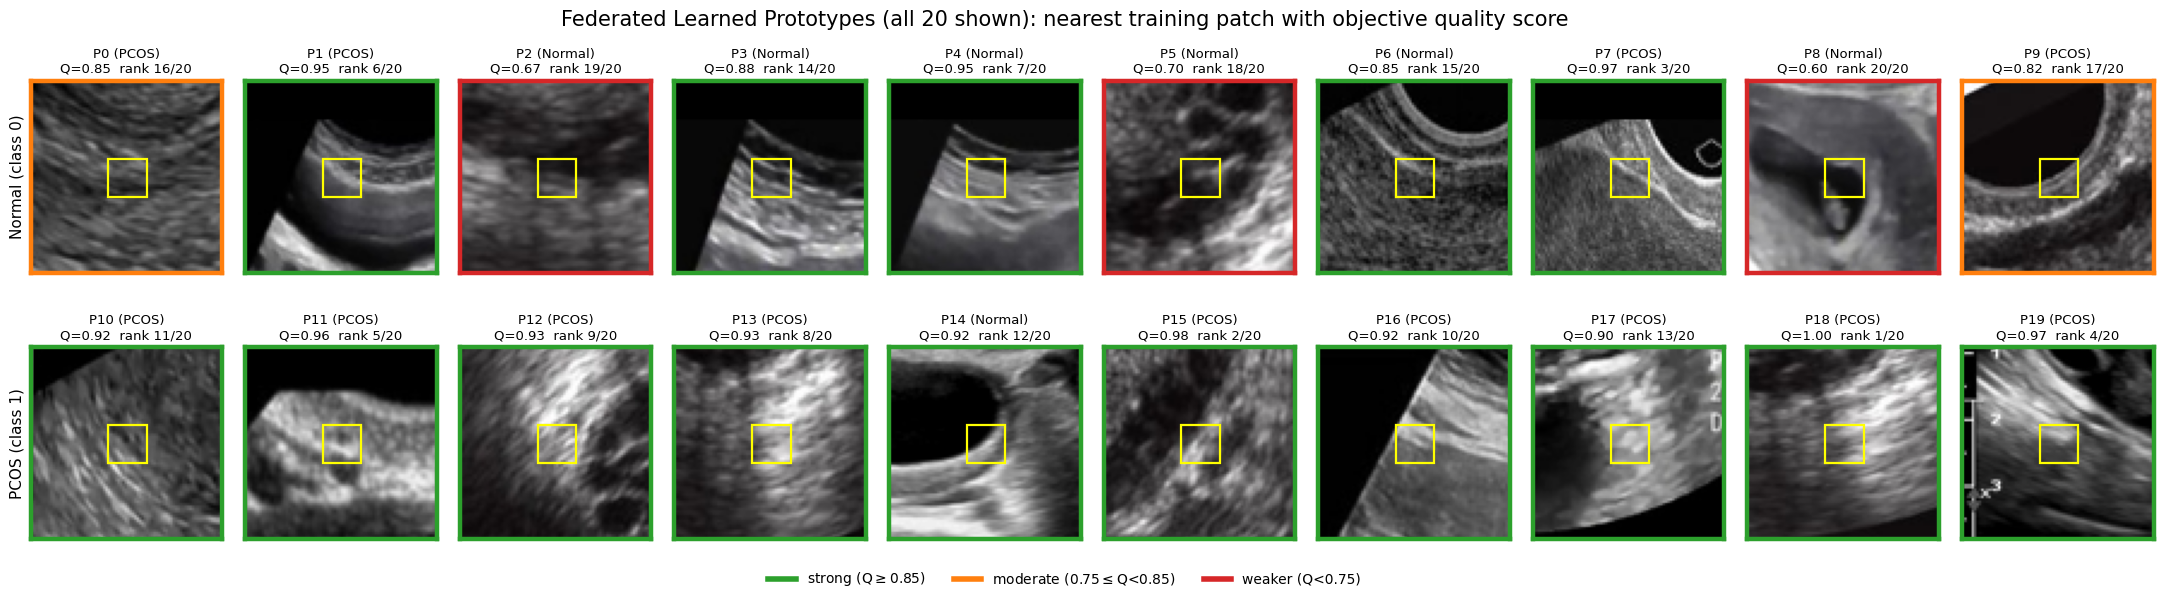

Saved prototype_gallery_honest.png / .svg


In [14]:
# ============================================================
# Cell: Honest prototype gallery + objective quality score (FL model)
# ============================================================
# Same trustworthy XAI artifact as the centralized notebook, but computed on the
# FEDERATED final model (fedproto_model). For every learned prototype we (1) find
# its single nearest TRAINING patch across the pooled training data using the
# exact tissue mask used in training, then (2) score that patch with a
# deterministic, reproducible quality metric and render ALL 20 prototypes in a
# transparent gallery. No prototype is hidden or hand-edited -- the gallery is a
# pure function of the checkpoint + training images + shipped mask band.
import numpy as np, json as _json
import scipy.ndimage as _ndi
import matplotlib
matplotlib.rcParams['font.family'] = ['Liberation Sans', 'DejaVu Sans']
matplotlib.rcParams['svg.fonttype'] = 'none'
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

from PIL import Image
from torch.utils.data import DataLoader
matplotlib.rcdefaults()
GRID = 14           # 14x14 patch grid for ViT-Base @ 224/16
PATCH_PX = 16       # each patch = 16x16 px in the 224x224 input
IMG_SIZE = 224

_gal_model = fedproto_model          # the federated final model
_gal_model.eval()

# Pooled training data across all sites (order preserved: shuffle=False)
all_train = []
for _s in SITE_NAMES:
    all_train += manifest[_s]['train']
_gal_loader = DataLoader(PCOSDataset(all_train), batch_size=32, shuffle=False, num_workers=2)

# --- Step 1: nearest masked training patch per prototype (cosine space) ---
proto_nearest = {}   # proto_idx -> dict(path, patch_idx, dist, label)
with torch.no_grad():
    protos_n = F.normalize(_gal_model.proto_layer.prototypes, dim=-1)   # (P, D)
    _n_proto = _gal_model.proto_layer.num_prototypes
    ptr = 0
    _fg_frac_sum = 0.0; _fg_n = 0; _zero_fg_imgs = 0
    for images, labels in _gal_loader:
        bsz = images.shape[0]
        imgs = images.to(DEVICE)
        pf = _gal_model.get_patch_features(imgs)          # (B, 196, D)
        pf_n = F.normalize(pf, dim=-1)
        sims = torch.matmul(pf_n, protos_n.t())           # (B, 196, P)
        dists = 2.0 - 2.0 * sims                          # cosine distance in [0,2]
        fgm = compute_patch_mask(imgs)                    # (B, 196) bool
        _fg_frac_sum += fgm.float().mean(dim=1).sum().item(); _fg_n += bsz
        _zero_fg_imgs += int((fgm.sum(dim=1) == 0).sum().item())
        for b in range(bsz):
            sample = all_train[ptr + b]
            fg_b = fgm[b]
            if fg_b.sum() == 0:                           # no tissue -> keep all
                fg_b = torch.ones_like(fg_b)
            for p in range(_n_proto):
                d_bp = dists[b, :, p].clone()
                d_bp[~fg_b] = float('inf')                # exclude background patches
                min_d, min_idx = d_bp.min(dim=0)
                md = min_d.item()
                if (p not in proto_nearest) or (md < proto_nearest[p]['dist']):
                    proto_nearest[p] = {'path': sample['path'],
                                        'patch_idx': int(min_idx.item()),
                                        'dist': md,
                                        'label': int(sample['label'])}
        ptr += bsz

# --- MASK CHECK: prove the tissue mask actually ran (same guard as centralized) ---
_mean_fg = _fg_frac_sum / max(_fg_n, 1)
print(f"[MASK CHECK] mean foreground fraction per image = {_mean_fg:.3f} "
      f"({100*(1-_mean_fg):.1f}% of patches masked out as background/rim)")
print(f"[MASK CHECK] images with ZERO tissue patches (fell back to all-patches) = {_zero_fg_imgs}")
assert _mean_fg < 0.98, ("Tissue mask appears INACTIVE: >98% of patches counted as foreground. "
                         "The v2 fan-erosion mask did not execute -- re-run the model-definition cell.")
assert _mean_fg > 0.02, ("Tissue mask OVER-EXCLUDES: <2% of patches kept. Check mask thresholds.")

# --- Step 2: objective, reproducible prototype quality score ---
_LOW, _HIGH = 0.15, 0.82          # identical band to compute_patch_mask
_TEX_CAP = 0.06                   # gradient at/above this -> full texture credit
_FAN_THR, _ERODE_PX = 0.06, 6     # identical fan params to compute_patch_mask

def _q_load_gray(path):
    im = Image.open(path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    return np.asarray(im, dtype=np.float32).mean(axis=2) / 255.0

def _q_fan_eroded(gray):
    lbl, n = _ndi.label(gray > _FAN_THR)
    if n == 0:
        return np.zeros_like(gray, dtype=bool)
    sz = _ndi.sum(np.ones_like(lbl), lbl, index=range(1, n + 1))
    big = _ndi.binary_fill_holes(lbl == (int(np.argmax(sz)) + 1))
    return _ndi.binary_erosion(big, iterations=_ERODE_PX) if _ERODE_PX > 0 else big

def _q_score(gray, pidx):
    r, c = pidx // GRID, pidx % GRID
    y0, y1, x0, x1 = r*PATCH_PX, (r+1)*PATCH_PX, c*PATCH_PX, (c+1)*PATCH_PX
    patch = gray[y0:y1, x0:x1]
    pmean = float(patch.mean())
    grad = float(np.abs(np.diff(patch, axis=1)).mean() + np.abs(np.diff(patch, axis=0)).mean())
    s_tex = min(1.0, grad / _TEX_CAP)
    if pmean < _LOW or pmean > _HIGH:
        s_bri = 0.0
    else:
        centre, halfw = 0.5*(_LOW+_HIGH), 0.5*(_HIGH-_LOW)
        s_bri = max(0.0, 1.0 - abs(pmean-centre)/halfw) ** 0.5
    s_fan = float(_q_fan_eroded(gray)[y0:y1, x0:x1].mean())
    quality = (max(s_tex,1e-6)*max(s_bri,1e-6)*max(s_fan,1e-6)) ** (1.0/3.0)
    return dict(pmean=pmean, grad=grad, s_tex=s_tex, s_bri=s_bri, s_fan=s_fan, quality=quality)

_q_rows = []
for _p in sorted(proto_nearest):
    _info = proto_nearest[_p]
    _sc = _q_score(_q_load_gray(_info['path']), _info['patch_idx'])
    _q_rows.append(dict(proto=int(_p), cls=int(_info['label']),
                        dist=round(float(_info['dist']), 4),
                        patch_idx=int(_info['patch_idx']),
                        path=_info['path'].split('/')[-1], **_sc))
_order = sorted(range(len(_q_rows)), key=lambda i: -_q_rows[i]['quality'])
for _rk, _i in enumerate(_order):
    _q_rows[_i]['rank'] = _rk + 1

_q = np.array([r['quality'] for r in _q_rows])
print('\n=== FL PROTOTYPE QUALITY SCORES (all 20, ranked) ===')
print(f'{"P":>3} {"cls":>4} {"qual":>5} {"rk":>3} {"tex":>5} {"bri":>5} {"fan":>5}')
for r in sorted(_q_rows, key=lambda r: r['rank']):
    print(f'{r["proto"]:>3} {("PCOS" if r["cls"] else "Norm"):>4} '
          f'{r["quality"]:>5.2f} {r["rank"]:>3} {r["s_tex"]:>5.2f} {r["s_bri"]:>5.2f} {r["s_fan"]:>5.2f}')
print(f'\nquality: mean={_q.mean():.3f} median={np.median(_q):.3f} '
      f'min={_q.min():.3f} max={_q.max():.3f} | '
      f'strong(>=0.85)={(_q>=0.85).sum()} moderate={((_q>=0.75)&(_q<0.85)).sum()} weaker(<0.75)={(_q<0.75).sum()}')

with open('/kaggle/working/prototype_quality_scores.json', 'w') as f:
    _json.dump(_q_rows, f, indent=2)
print('Saved prototype_quality_scores.json')

# --- Step 3: transparent annotated gallery (all 20, colored by quality tier) ---
_CTX = 2; _CANVAS = (2*_CTX + 1) * PATCH_PX
def _q_canvas(rgb, pidx):
    r, c = pidx // GRID, pidx % GRID
    y0, x0 = (r-_CTX)*PATCH_PX, (c-_CTX)*PATCH_PX
    cv = np.zeros((_CANVAS, _CANVAS, 3), dtype=np.uint8)
    sy0, sy1 = max(0,y0), min(IMG_SIZE, y0+_CANVAS)
    sx0, sx1 = max(0,x0), min(IMG_SIZE, x0+_CANVAS)
    cv[sy0-y0:sy0-y0+(sy1-sy0), sx0-x0:sx0-x0+(sx1-sx0)] = rgb[sy0:sy1, sx0:sx1]
    return cv
def _tier(q): return '#2ca02c' if q>=0.85 else ('#ff7f0e' if q>=0.75 else '#d62728')
_scmap = {r['proto']: r for r in _q_rows}
_fig, _axes = plt.subplots(2, 10, figsize=(22, 6.0))
_fig.suptitle('Federated Learned Prototypes (all 20 shown): nearest training patch with objective quality score', fontsize=15, y=0.99)
for _p in range(len(_q_rows)):
    _ax = _axes[_p//10, _p%10]; _info = proto_nearest[_p]; _r = _scmap[_p]
    _rgb = np.asarray(Image.open(_info['path']).convert('RGB').resize((IMG_SIZE,IMG_SIZE)), dtype=np.uint8)
    _ax.imshow(_q_canvas(_rgb, _info['patch_idx']), aspect='equal')
    _ax.add_patch(Rectangle((_CTX*PATCH_PX, _CTX*PATCH_PX), PATCH_PX, PATCH_PX, fill=False, edgecolor='yellow', linewidth=1.6))
    _ax.set_title(f'P{_p} ({"PCOS" if _r["cls"] else "Normal"})\nQ={_r["quality"]:.2f}  rank {_r["rank"]}/{len(_q_rows)}', fontsize=9.5)
    for _s in _ax.spines.values(): _s.set_edgecolor(_tier(_r['quality'])); _s.set_linewidth(3.2)
    _ax.set_xticks([]); _ax.set_yticks([])
_axes[0,0].set_ylabel('Normal (class 0)', fontsize=11); _axes[1,0].set_ylabel('PCOS (class 1)', fontsize=11)
_fig.legend(handles=[Line2D([0],[0],color='#2ca02c',lw=4,label='strong (Q$\\geq$0.85)'),
                     Line2D([0],[0],color='#ff7f0e',lw=4,label='moderate (0.75$\\leq$Q<0.85)'),
                     Line2D([0],[0],color='#d62728',lw=4,label='weaker (Q<0.75)')],
            loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, 0.005), frameon=False)
_fig.subplots_adjust(left=0.03, right=0.995, top=0.88, bottom=0.10, wspace=0.12, hspace=0.32)
_fig.savefig('/kaggle/working/prototype_gallery_honest.png', dpi=200)
_fig.savefig('/kaggle/working/prototype_gallery_honest.svg')
plt.show()
print('Saved prototype_gallery_honest.png / .svg')


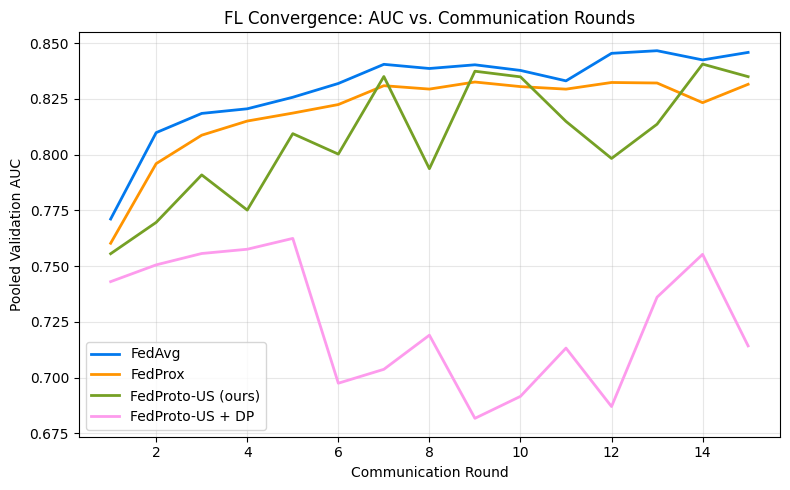

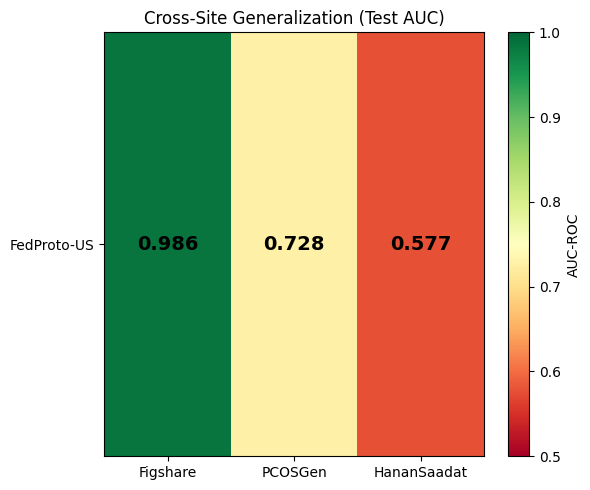

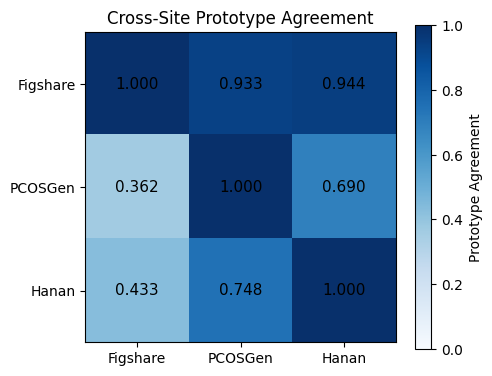

All figures saved.


In [15]:
# ============================================================
# Cell 12: Generate all figures
# ============================================================

# Fig 1: Convergence curves
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
for exp, label, color in [('fedavg', 'FedAvg', '#0279EE'), ('fedprox', 'FedProx', '#FF9400'),
                           ('fedproto_us', 'FedProto-US (ours)', '#75A025'),
                           ('fedproto_us_dp3', 'FedProto-US + DP', '#FD9BED')]:
    if exp not in all_results:   # skip experiments not run in this session (e.g. core-run-only)
        continue
    aucs = [h['pooled']['auc'] for h in all_results[exp]]
    ax.plot(range(1, len(aucs)+1), aucs, color=color, label=label, linewidth=2)
ax.set_xlabel('Communication Round'); ax.set_ylabel('Pooled Validation AUC')
ax.set_title('FL Convergence: AUC vs. Communication Rounds')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/fl_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

# Fig 2: Cross-site generalization heatmap
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
test_aucs = np.array([[cross_site_results['fedproto_us'][f'{s}_test']['auc'] for s in SITE_NAMES]])
im = ax.imshow(test_aucs, cmap='RdYlGn', vmin=0.5, vmax=1.0, aspect='auto')
ax.set_xticks(range(3)); ax.set_xticklabels(['Figshare', 'PCOSGen', 'HananSaadat'])
ax.set_yticks([0]); ax.set_yticklabels(['FedProto-US'])
for i in range(3):
    ax.text(i, 0, f'{test_aucs[0,i]:.3f}', ha='center', va='center', fontsize=14, fontweight='bold')
plt.colorbar(im, label='AUC-ROC')
ax.set_title('Cross-Site Generalization (Test AUC)')
plt.tight_layout()
plt.savefig('/kaggle/working/cross_site_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Fig 3: Prototype agreement matrix
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
im = ax.imshow(final_agreement, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(3)); ax.set_xticklabels(['Figshare', 'PCOSGen', 'Hanan'])
ax.set_yticks(range(3)); ax.set_yticklabels(['Figshare', 'PCOSGen', 'Hanan'])
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{final_agreement[i,j]:.3f}', ha='center', va='center', fontsize=11)
plt.colorbar(im, label='Prototype Agreement')
ax.set_title('Cross-Site Prototype Agreement')
plt.tight_layout()
plt.savefig('/kaggle/working/prototype_agreement.png', dpi=150, bbox_inches='tight')
plt.show()

print('All figures saved.')

In [16]:
# ============================================================
# Cell 13: Save all results
# ============================================================
results = {
    'experiments': all_results,
    'cross_site': cross_site_results,
    'prototype_agreement': {
        'final_matrix': final_agreement.tolist(),
        'agreement_over_rounds': agreement_over_rounds,
        'spearman_rho': rho, 'spearman_p': pval,
    },
    'config': {
        'num_rounds': NUM_ROUNDS, 'local_epochs': LOCAL_EPOCHS,
        'batch_size': BATCH_SIZE, 'backbone': 'USFM ViT-Base (frozen)',
        'lora_rank': 8, 'proto_per_class': 10,
        'sites': SITE_NAMES,
        'site_sizes': {s: len(manifest[s]['train']) for s in SITE_NAMES},
    }
}

with open('/kaggle/working/fl_results.json', 'w') as f:
    json.dump(results, f, indent=2)

# Save FedProto-US model checkpoint
torch.save({
    'lora_state': get_lora_state(fedproto_model),
    'proto_state': fedproto_model.proto_layer.state_dict(),
    'classifier_state': fedproto_model.classifier.state_dict(),
}, '/kaggle/working/fedproto_us_model.pth')

# Persist per-image predictions if the baseline-eval cell (10b) produced them.
if 'fl_predictions' in globals():
    with open('/kaggle/working/fl_predictions.json', 'w') as f:
        json.dump(fl_predictions, f)
    print('Saved: fl_predictions.json (per-image labels+probs for CIs/DeLong)')

print('Saved: fl_results.json, fedproto_us_model.pth')
print('Saved: fl_convergence.png, cross_site_heatmap.png, prototype_agreement.png')
print('Saved: prototype_quality_scores.json, prototype_gallery_honest.png/.svg')
print('\n=== EXPERIMENT SUMMARY ===')
for exp in ['fedproto_us', 'fedavg', 'fedprox', 'fedproto_us_dp3']:
    if exp not in all_results:   # only summarize experiments actually run this session
        continue
    final_auc = all_results[exp][-1]['pooled']['auc']
    print(f'  {exp}: final pooled AUC = {final_auc:.3f}')

Saved: fl_predictions.json (per-image labels+probs for CIs/DeLong)
Saved: fl_results.json, fedproto_us_model.pth
Saved: fl_convergence.png, cross_site_heatmap.png, prototype_agreement.png
Saved: prototype_quality_scores.json, prototype_gallery_honest.png/.svg

=== EXPERIMENT SUMMARY ===
  fedproto_us: final pooled AUC = 0.835
  fedavg: final pooled AUC = 0.846
  fedprox: final pooled AUC = 0.832
  fedproto_us_dp3: final pooled AUC = 0.714
